# Import

In [3]:
from datetime import datetime
from zoneinfo import ZoneInfo


In [5]:
now = datetime.now(ZoneInfo("Asia/Shanghai"))

# 格式化成 yyyymmddhhmmss 字符串
time_str = now.strftime("%Y%m%d%H%M%S")

print(time_str)

20260412161250


In [6]:
import os

In [7]:
os.path.join('/c', 'test', 'te', 'er')

'/c/test/te/er'

In [1]:
import asyncio
import os
import base64
import json
from typing import Literal, Tuple, Annotated, Optional, Union, List, Any, Dict, Sequence

from pydantic import BaseModel, Field, ConfigDict

import math
import base64
import copy
from io import BytesIO
from PIL import ImageColor, Image, ImageDraw, ImageFont

from transformers import Qwen3VLMoeForConditionalGeneration, Qwen3VLForConditionalGeneration, AutoProcessor

from agentscope.agent import ReActAgent, UserAgent
from agentscope.formatter import OpenAIChatFormatter, OpenAIMultiAgentFormatter
from agentscope.memory import InMemoryMemory
from agentscope.model import OpenAIChatModel
from agentscope.agent import ReActAgent
from agentscope.tool import ToolResponse, Toolkit, execute_python_code, write_text_file
from agentscope.message import (
    Msg,
    Base64Source,
    TextBlock,
    URLSource,
    ThinkingBlock,
    ImageBlock,
    ToolUseBlock,
    ToolResultBlock,
)
import requests
import openai
import openslide
import uuid
import shortuuid
import numpy as np
import cv2
import matplotlib.pyplot as plt
# from qwen_vl_utils import process_vision_info, extract_vision_info

# Load WSI image

In [32]:
Reg_path = '/mnt/raid5/zhangchen/datasets/Reg2025/REG_train/PIT_01_00004_01.tiff'
TCGA_path = '/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/TCGA-AN-A0G0-01Z-00-DX1.BE0BB5DF-DEDA-48D8-B5D8-2735C767F28F.svs'
HistAI_path = '/mnt/raid5/zhangchen/datasets/HISTAI/HISTAI-breast/case_1551/slide_H&E_0.tiff'
reg_sample = openslide.OpenSlide(Reg_path)
tcga_sample = openslide.OpenSlide(TCGA_path)
histai_sample = openslide.OpenSlide(HistAI_path)

In [11]:
w, h = reg_sample.dimensions
image_test = reg_sample.read_region((0, 0), 0, (w, h)).resize((1024, 1024) ,Image.Resampling.LANCZOS)

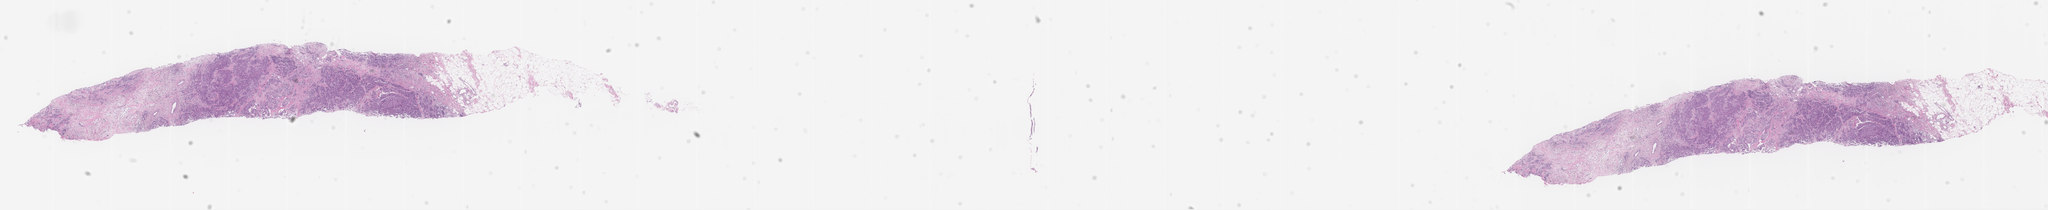

In [14]:
reg_sample.get_thumbnail((2048, 2048))

In [35]:
reg_sample.properties['openslide.mpp-x']

'1000'

In [44]:
dict(reg_sample.properties)

{'openslide.level-count': '1',
 'openslide.level[0].downsample': '1',
 'openslide.level[0].height': '7162',
 'openslide.level[0].tile-height': '256',
 'openslide.level[0].tile-width': '256',
 'openslide.level[0].width': '69785',
 'openslide.mpp-x': '1000',
 'openslide.mpp-y': '1000',
 'openslide.vendor': 'generic-tiff',
 'tiff.ResolutionUnit': 'centimeter',
 'tiff.XResolution': '10',
 'tiff.YResolution': '10'}

In [38]:
for wsi_filename in os.listdir('/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs'):
    wsi_path = os.path.join('/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs', wsi_filename)
    wsi_sample = openslide.OpenSlide(wsi_path)
    print(wsi_sample.properties['openslide.mpp-x'])
    if float(wsi_sample.properties['openslide.mpp-x']) > 0.26:
        print(wsi_path)

0.24679999999999999
0.248
0.248
0.49919999999999998
/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/TCGA-AO-A0J3-01Z-00-DX1.8F28BFC8-D37E-425F-A9E3-4C23F083237C.svs
0.2505
0.25269999999999998
0.2525
0.2505
0.24679999999999999
0.49790000000000001
/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/TCGA-AO-A1KS-01Z-00-DX1.349F9BCA-C9F0-43B4-BA6A-D20039E1C720.svs
0.2485
0.2505
0.24560000000000001
0.24560000000000001
0.2485
0.23250000000000001
0.23250000000000001
0.2485
0.24560000000000001
0.2505
0.248
0.2465
0.25269999999999998
0.23250000000000001
0.248
0.24679999999999999
0.2485
0.25269999999999998
0.24679999999999999
0.25269999999999998
0.49919999999999998
/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/TCGA-AO-A0JC-01Z-00-DX1.C8DD421B-9799-4FE7-9224-5EAC6ED1028E.svs
0.24560000000000001
0.23250000000000001
0.24679999999999999
0.2505
0.24679999999999999
0.24560000000000001
0.248
0.248
0.24679999999999999
0.248
0.248
0.2465
0.49919999999999998
/data/home/zhangchen/datasets/TCGA/WSI/BRCA_svs/T

## Reg 20x mpp directly equal 0.5

In [23]:
tcga_sample.properties.get("aperio.MPP")

'0.2480'

In [26]:
reg_sample.properties.get("hamamatsu.XResolution")

In [39]:
import json

In [42]:
json.reads(histai_sample.properties)

AttributeError: module 'json' has no attribute 'reads'

In [ ]:
histai_sample.properties

<_PropertyMap {'openslide.comment': '{"shape": [38129, 28105, 3]}', 'openslide.level-count': '5', 'openslide.level[0].downsample': '1', 'openslide.level[0].height': '38129', 'openslide.level[0].tile-height': '4096', 'openslide.level[0].tile-width': '4096', 'openslide.level[0].width': '28105', 'openslide.level[1].downsample': '2.000061809567939', 'openslide.level[1].height': '19064', 'openslide.level[1].tile-height': '4096', 'openslide.level[1].tile-width': '4096', 'openslide.level[1].width': '14052', 'openslide.level[2].downsample': '4.000123619135878', 'openslide.level[2].height': '9532', 'openslide.level[2].tile-height': '4096', 'openslide.level[2].tile-width': '4096', 'openslide.level[2].width': '7026', 'openslide.level[3].downsample': '8.000247238271756', 'openslide.level[3].height': '4766', 'openslide.level[3].tile-height': '4096', 'openslide.level[3].tile-width': '4096', 'openslide.level[3].width': '3513', 'openslide.level[4].downsample': '16.002772461924202', 'openslide.level[4]

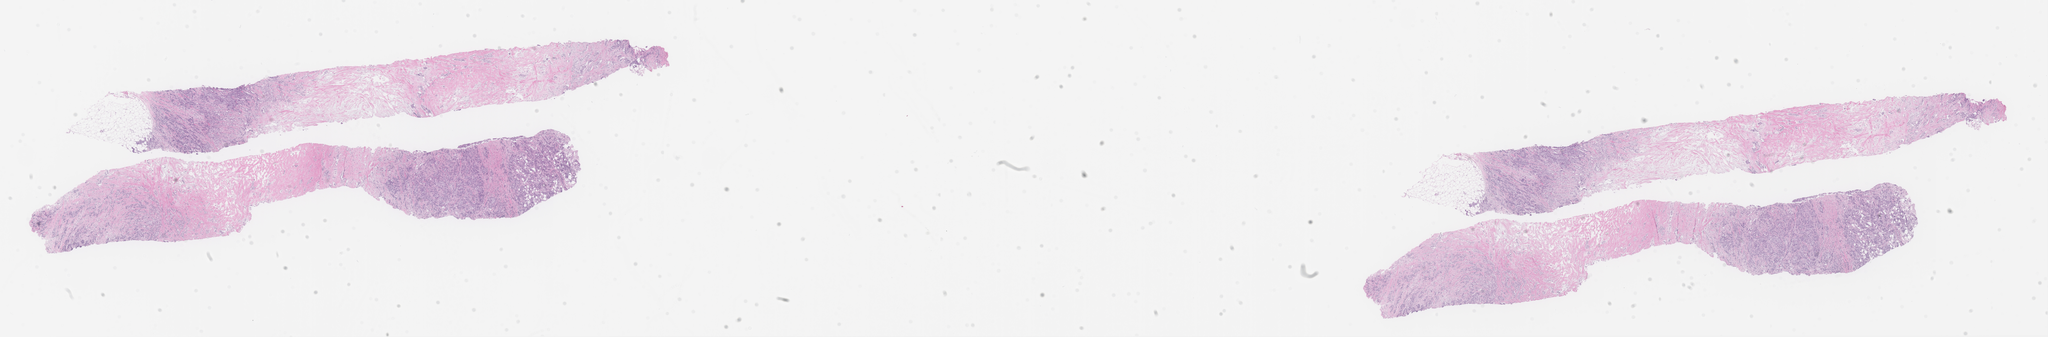

In [21]:
Reg_path = '/mnt/raid5/zhangchen/datasets/Reg2025/REG_train/PIT_01_00007_01.tiff'
reg_sample = openslide.OpenSlide(Reg_path)
reg_sample.properties
reg_sample.get_thumbnail((2048, 2048))

In [27]:
from utils.image_utils import infer_level0_mpp

In [31]:
infer_level0_mpp(slide=tcga_sample, override_level0_mpp=None)

0.248

# Base WSI tools